# Momentum : lookback, turnover et coûts de transaction

Ce notebook approfondit l'étude momentum du notebook 03 sous l'angle des **coûts**. On veut répondre à trois questions et les relier :
1. **Pourquoi retenir le momentum 3 mois ?** (meilleur Sharpe, brut *et* net)
2. **Pourquoi les coûts mordent-ils sur le momentum** alors qu'ils sont négligeables sur le SMA ? (réponse : le **turnover**)
3. **Quel est l'impact chiffré** des coûts sur chaque lookback ?

Rappel du modèle : momentum transversal (cross-sectional), rééquilibrage mensuel, on achète les $K=3$ meilleurs titres sur 8 à poids égal, poids décalés d'un mois (anti-look-ahead). Coût proportionnel : $\text{coût}_t = \text{turnover}_t \times (\text{commission}+\text{slippage})$, avec $\text{turnover}_t = \sum_i |w_{i,t}-w_{i,t-1}|$.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

adj = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
UNIV = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]
K = 3
COST_BPS = 20 / 1e4        # 10 bps commission + 10 bps slippage
LOOKBACKS = [1, 3, 6, 12]

mpx = adj[UNIV].resample("ME").last()      # prix mensuels (fin de mois)
mret = mpx.pct_change()

def momentum(lb):
    """Retourne (rendements bruts, rendements nets, turnover) pour un lookback lb (mois)."""
    sig = mpx / mpx.shift(lb) - 1                       # rendement passé sur lb mois
    rank = sig.rank(axis=1, ascending=False)
    w = (rank <= K).astype(float)
    w = w.div(w.sum(axis=1), axis=0)                    # top-K équipondéré
    gross = (w.shift(1) * mret).sum(axis=1)             # poids appliqués au mois suivant
    turn = (w - w.shift(1)).abs().sum(axis=1)           # turnover par rééquilibrage
    net = gross - turn.shift(1) * COST_BPS
    return gross.dropna(), net.dropna(), turn.dropna()

def sharpe(r): return r.mean() / r.std() * np.sqrt(12)  # mensuel -> annualisé
def equity(r): return (1 + r).cumprod()

res = {lb: momentum(lb) for lb in LOOKBACKS}

## 1. Courbes d'équité par lookback (brut) — version arrangée

Le graphique du notebook 03, remis au propre : équité cumulée (échelle log) de chaque lookback, avec le Sharpe brut en légende.

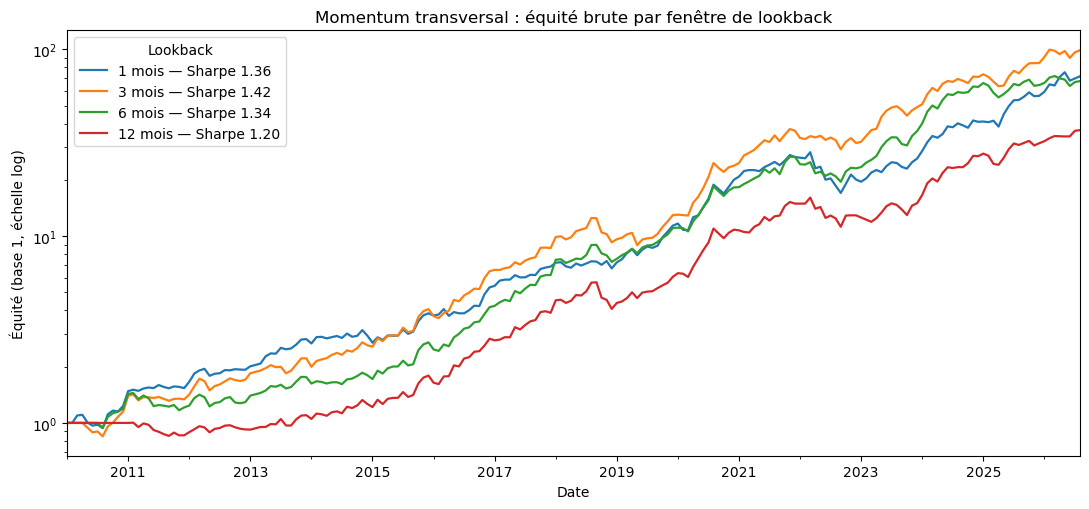

In [2]:
fig, ax = plt.subplots(figsize=(11, 5.2))
for lb in LOOKBACKS:
    g, _, _ = res[lb]
    equity(g).plot(ax=ax, lw=1.6, label=f"{lb} mois — Sharpe {sharpe(g):.2f}")
ax.set_yscale("log"); ax.set_ylabel("Équité (base 1, échelle log)")
ax.set_title("Momentum transversal : équité brute par fenêtre de lookback")
ax.legend(title="Lookback"); plt.tight_layout(); plt.show()

## 2. Turnover par lookback : l'intensité de trading

Le turnover mesure combien le portefeuille se réarrange à chaque rééquilibrage. Une fenêtre **courte** (1 mois) réagit vite au bruit → turnover élevé ; une fenêtre **longue** est stable → turnover faible. C'est la clé de tout ce qui suit.

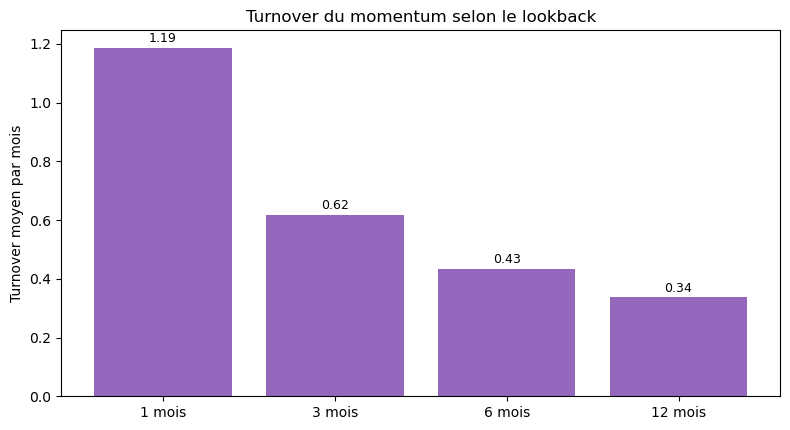

Turnover total sur la période : {'1m': np.float64(237.3), '3m': np.float64(123.3), '6m': np.float64(86.7), '12m': np.float64(67.3)}


In [3]:
turn_mean = {lb: res[lb][2].mean() for lb in LOOKBACKS}
turn_tot = {lb: res[lb][2].sum() for lb in LOOKBACKS}

fig, ax = plt.subplots(figsize=(8, 4.4))
x = np.arange(len(LOOKBACKS))
ax.bar(x, [turn_mean[lb] for lb in LOOKBACKS], color="tab:purple")
for i, lb in enumerate(LOOKBACKS):
    ax.text(i, turn_mean[lb] + 0.02, f"{turn_mean[lb]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"{lb} mois" for lb in LOOKBACKS])
ax.set_ylabel("Turnover moyen par mois"); ax.set_title("Turnover du momentum selon le lookback")
plt.tight_layout(); plt.show()
print("Turnover total sur la période :", {f"{lb}m": round(turn_tot[lb], 1) for lb in LOOKBACKS})

## 3. Équité brute contre nette, par lookback

Pour chaque fenêtre, on superpose l'équité **sans coûts** et **avec coûts** (10+10 bps). L'écart entre les deux courbes est directement l'effet des coûts — et il est visiblement plus grand pour les fenêtres courtes (fort turnover).

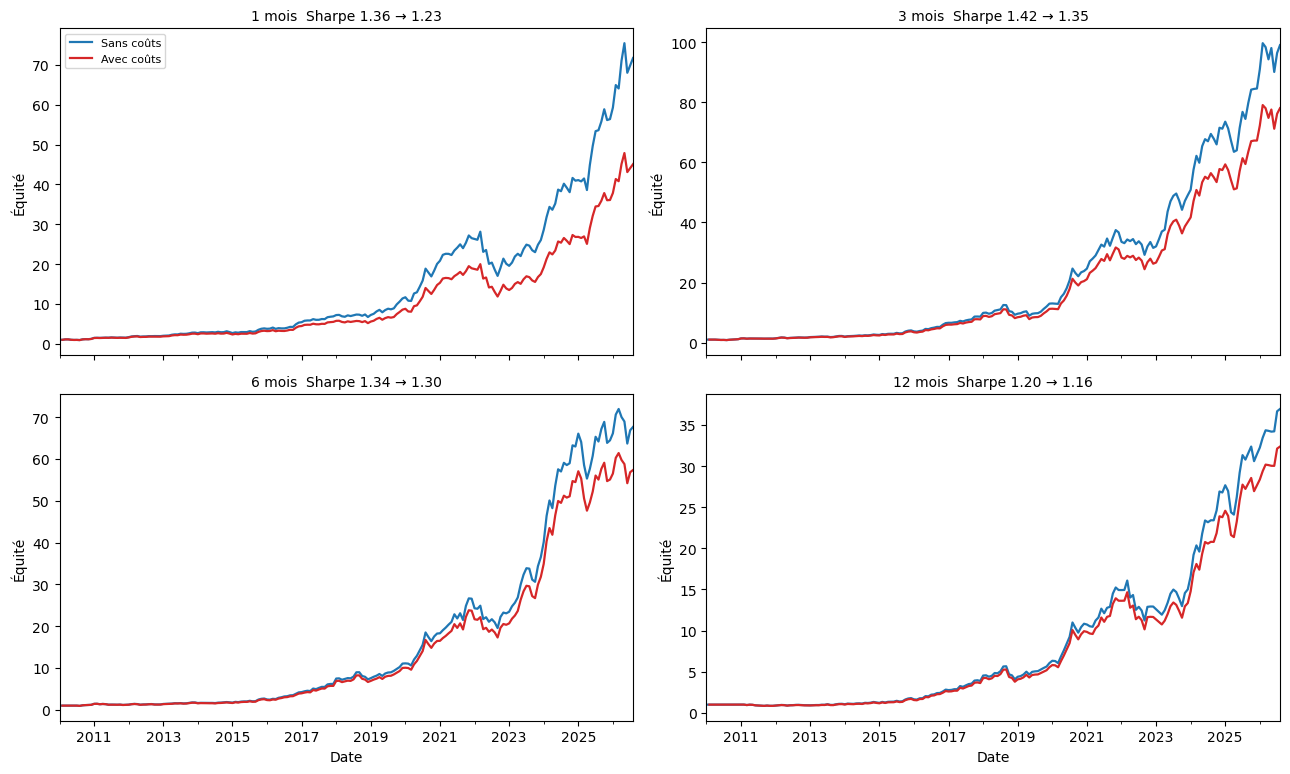

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, lb in zip(axes.ravel(), LOOKBACKS):
    g, n, _ = res[lb]
    equity(g).plot(ax=ax, lw=1.6, label="Sans coûts", color="tab:blue")
    equity(n).plot(ax=ax, lw=1.6, label="Avec coûts", color="tab:red")
    perte = equity(n).iloc[-1] / equity(g).iloc[-1] - 1
    ax.set_title(f"{lb} mois  Sharpe {sharpe(g):.2f} → {sharpe(n):.2f}", fontsize=10)
    ax.set_ylabel("Équité")
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Sharpe brut vs net et choix du lookback

On récapitule. Le **3 mois** maximise le Sharpe **à la fois brut et net** : assez long pour éviter le turnover destructeur du 1 mois, assez court pour capter la dynamique. C'est la justification chiffrée du choix.

          Sharpe brut  Sharpe net  Δ Sharpe (coûts)  Turnover moyen
Lookback                                                           
1 mois          1.364       1.227            -0.136           1.187
3 mois          1.415       1.352            -0.063           0.617
6 mois          1.341       1.297            -0.044           0.433
12 mois         1.197       1.161            -0.037           0.337

=> Meilleur Sharpe NET : 3 mois


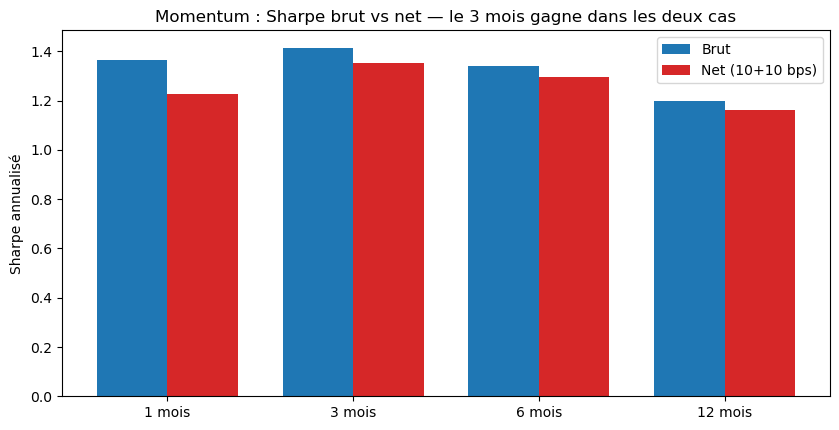

In [5]:
rows = []
for lb in LOOKBACKS:
    g, n, t = res[lb]
    rows.append({"Lookback": f"{lb} mois", "Sharpe brut": sharpe(g), "Sharpe net": sharpe(n),
                 "Δ Sharpe (coûts)": sharpe(n) - sharpe(g), "Turnover moyen": t.mean()})
tab = pd.DataFrame(rows).set_index("Lookback").round(3)
print(tab.to_string())
best = tab["Sharpe net"].idxmax()
print(f"\n=> Meilleur Sharpe NET : {best}")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
x = np.arange(len(LOOKBACKS)); w = 0.38
ax.bar(x - w/2, tab["Sharpe brut"], w, label="Brut", color="tab:blue")
ax.bar(x + w/2, tab["Sharpe net"], w, label="Net (10+10 bps)", color="tab:red")
ax.set_xticks(x); ax.set_xticklabels(tab.index); ax.set_ylabel("Sharpe annualisé")
ax.set_title("Momentum : Sharpe brut vs net — le 3 mois gagne dans les deux cas")
ax.legend(); plt.tight_layout(); plt.show()

## 5. La preuve : la perte de Sharpe est proportionnelle au turnover

On trace la perte de Sharpe due aux coûts en fonction du turnover moyen. Les points s'alignent : **plus une stratégie tourne, plus elle paie**. C'est le mécanisme central de la section coûts.

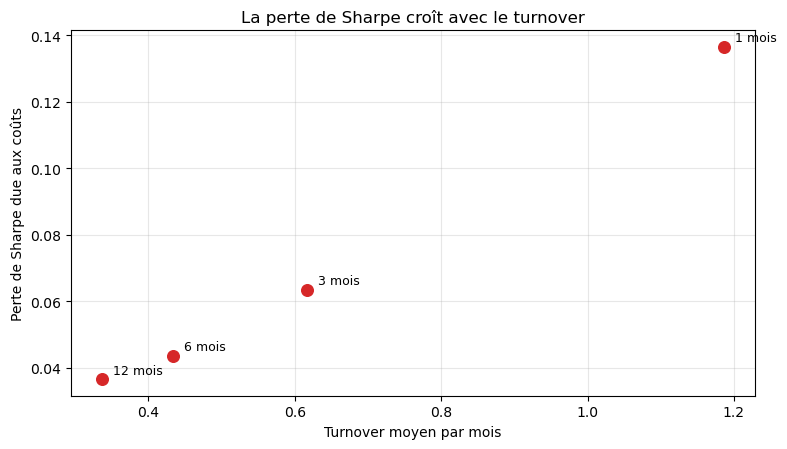

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for lb in LOOKBACKS:
    _, _, t = res[lb]; g, n, _ = res[lb]
    ax.scatter(t.mean(), sharpe(g) - sharpe(n), s=70, color="tab:red")
    ax.annotate(f"{lb} mois", (t.mean(), sharpe(g) - sharpe(n)),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Turnover moyen par mois"); ax.set_ylabel("Perte de Sharpe due aux coûts")
ax.set_title("La perte de Sharpe croît avec le turnover")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 6. Le contraste avec le SMA : pourquoi les coûts n'y font rien

Le SMA change de position une vingtaine de fois en seize ans, soit un turnover **annualisé** dérisoire face au momentum. On compare directement le turnover annualisé des deux stratégies : le momentum tourne un **ordre de grandeur** plus vite → les coûts le concernent, pas le SMA.

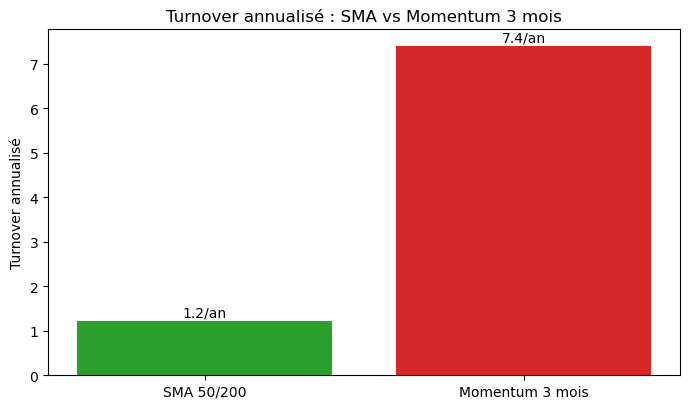

SMA : 1.23 changements/an  |  Momentum 3 mois : 7.4 de turnover/an  (≈ 6x plus)


In [7]:
import sys, queue; sys.path.insert(0, "../src")
from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

years = (adj.index[-1] - adj.index[0]).days / 365.25
# turnover annualisé du SMA : moyenne sur les 8 titres du nombre de changements de position / an
sma_turn = []
for t in UNIV:
    ev = queue.Queue(); d = HistoricCSVDataHandler(ev, adj[[t]], [t]); d.events = ev
    s = MovingAverageCrossStrategy(d, ev, [t], 50, 200)
    p = Portfolio(d, ev, [t], adj.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, 0, 0)
    ec = run_backtest(d, s, p, x)
    sma_turn.append((ec[f"pos_{t}"].diff().abs() > 0).sum() / years)
sma_ann = np.mean(sma_turn)
mom3_ann = res[3][2].mean() * 12   # turnover mensuel -> annualisé

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(["SMA 50/200", "Momentum 3 mois"], [sma_ann, mom3_ann], color=["tab:green", "tab:red"])
for i, v in enumerate([sma_ann, mom3_ann]):
    ax.text(i, v + 0.1, f"{v:.1f}/an", ha="center", fontsize=10)
ax.set_ylabel("Turnover annualisé"); ax.set_title("Turnover annualisé : SMA vs Momentum 3 mois")
plt.tight_layout(); plt.show()
print(f"SMA : {sma_ann:.2f} changements/an  |  Momentum 3 mois : {mom3_ann:.1f} de turnover/an  "
      f"(≈ {mom3_ann/sma_ann:.0f}x plus)")

## Ce qu'on retient

- **Choix du 3 mois** : il a le meilleur Sharpe **net** (et brut). Le 1 mois a un Sharpe brut proche mais son turnover élevé le fait chuter après coûts ; les fenêtres longues sont trop lentes.
- **Les coûts sont pilotés par le turnover** : la perte de Sharpe s'aligne sur le turnover moyen (section 5). C'est une loi, pas un accident.
- **Pourquoi rien sur le SMA** : son turnover annualisé est un ordre de grandeur plus faible que celui du momentum (section 6). Un modèle de coûts, même sophistiqué, ne changerait pas ce constat — l'insensibilité du SMA aux coûts est un **résultat robuste**, pas un manque d'information.